# The simplest RL problem: the 2-armed bandit.

> **NOTE:**
> this code and explanation are written by hand :)

The simplest RL problem is the two-armed bandit: 

**The 'Bandit' is a machine with 2 levers, A and B, each of which has a hidden probability distribution determining the reward returned when the lever is pulled. The 'Agent' attempts to maximize the cumulative reward received from the bandit using an epsilon-greedy approach.**

### setting up the bandit

In [2]:
import numpy as np 
import random

In [12]:
# distribution A - higher expected value, lower variance
muA = 1
sigA = 0.5
# distribution B
muB = 0.5 
sigB = 0.5

def leverA():
    return np.random.normal(muA, sigA)

def leverB():
    return np.random.normal(muB, sigB)

In [13]:
class EpsilonGreedyAgent: 

    def __init__(self, epsilon):
        self.epsilon = epsilon
        self.total = 0
        self.estA = 0 
        self.estB = 0
        self.triesA = 0 
        self.triesB = 0

    def try_lever(self): 
        pick = random.uniform(0, 1) 
        if (self.estA > self.estB and pick > self.epsilon) or (self.estA < self.estB and pick <= self.epsilon): 
            val = leverA()
            self.triesA += 1
            self.estA = self.estA * ((self.triesA - 1) / self.triesA) + val / self.triesA
        else:
            val = leverB()
            self.triesB += 1
            self.estB = self.estB * ((self.triesB - 1) / self.triesB) + val / self.triesB
        self.total += val

In [14]:
def bandit_experiment(num_tries, epsilon):
    agent = EpsilonGreedyAgent(epsilon)
    for i in range(num_tries): 
        agent.try_lever()
    return agent.total / num_tries, agent.estA, agent.estB

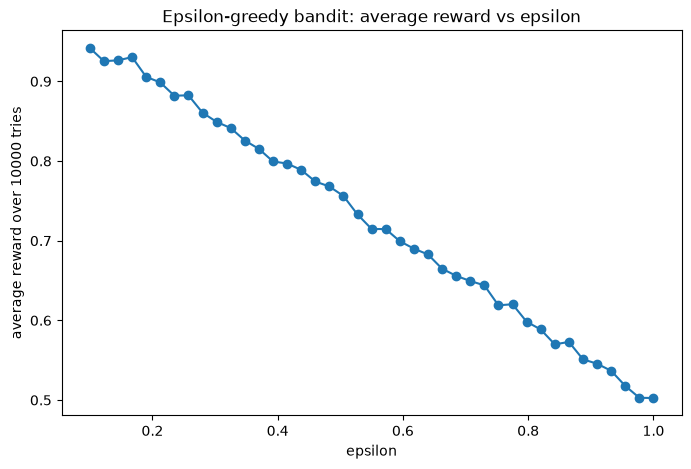

In [15]:
import matplotlib.pyplot as plt

num_tries = 10000
epsilons = np.linspace(0.1, 1, 41)
avg_rewards = [bandit_experiment(num_tries, eps)[0] for eps in epsilons]

plt.figure(figsize=(8, 5))
plt.plot(epsilons, avg_rewards, marker='o')
plt.xlabel('epsilon')
plt.ylabel(f'average reward over {num_tries} tries')
plt.title('Epsilon-greedy bandit: average reward vs epsilon')
plt.show()